## CliffWalking: Dynamic Programming under High-Risk Reward Structures

### Overview
This notebook studies **Value Iteration (VI)** and **Policy Iteration (PI)** on the **CliffWalking-v0** environment, a classic gridworld that highlights the trade-off between optimality and risk in reinforcement learning. Unlike FrozenLake, CliffWalking features deterministic transitions combined with **large negative rewards**, making policy behavior highly sensitive to mistakes.

### Environment Setup
- **Environment:** `CliffWalking-v0`
- **Grid Size:** 4 × 12
- **Dynamics:** Deterministic
- **State Space:** 48 discrete states
- **Action Space:** 4 actions (Up, Right, Down, Left)
- **Reward Structure:**
  - Step cost: −1
  - Falling into the cliff: −100 (episode reset)
  - Reaching the goal: episode termination

The cliff region creates a strong incentive to balance shortest-path behavior against catastrophic penalties.

### Objectives
The objectives of this notebook are to:
1. Apply **Value Iteration** and **Policy Iteration** to a deterministic but risk-sensitive MDP.
2. Compare their convergence behavior and resulting value functions.
3. Visualize how extreme negative rewards shape the learned policies.
4. Empirically evaluate policy performance based on cumulative episode returns.

### Methodology
Both algorithms are implemented using the full transition model provided by the environment. Learned policies are evaluated through repeated rollouts, and results are analyzed using convergence plots and value-function visualizations to understand how optimal behavior emerges under severe penalties.


### Imports

In [1]:
import gym
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from algorithms.value_iteration import value_iteration
from algorithms.policy_iteration import policy_iteration
from utils.utils import evaluate_policy, plot_convergence

### Create "CliffWalking" Environment

In [2]:
import random
seed = 26
np.random.seed(seed)
random.seed(seed)

env = gym.make("CliffWalking-v0")
env.seed(seed)
env.action_space.seed(seed)

env.reset()
print("States:", env.observation_space.n)
print("Actions:", env.action_space.n)

States: 48
Actions: 4


### Random Actions in Env

In [3]:
import time
from IPython.display import clear_output

state = env.reset()

done = False
step = 0

# while not done:
for _ in range(20):
    clear_output(wait=True)

    # Render ANSI text
    print(env.render(mode="ansi"))

    action = env.action_space.sample()
    next_state, reward, done, info = env.step(action)

    print(f"Step: {step}")
    print(f"State: {state} -> {next_state}")
    print(f"Action: {action}")
    print(f"Reward: {reward}")
    print(f"Done: {done}")

    state = next_state
    step += 1
    time.sleep(0.6)

env.close()
print("Episode finished.")

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
x  o  o  o  o  o  o  o  o  o  o  o
o  C  C  C  C  C  C  C  C  C  C  T


Step: 19
State: 24 -> 24
Action: 3
Reward: -1
Done: False
Episode finished.


### Running "*Value Iteration*"

In [4]:
policy_vi, V_vi, iterations_vi, time_taken_vi, deltas_vi = value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100000)
print("Value Iteration Completed")
print("VI State Values:\n", V_vi.reshape(4, 12))

Value Iteration Completed
VI State Values:
 [[-13.12541872 -12.2478977  -11.36151283 -10.46617457  -9.5617925
   -8.64827525  -7.72553056  -6.79346521  -5.85198506  -4.90099501
   -3.940399    -2.9701    ]
 [-12.2478977  -11.36151283 -10.46617457  -9.5617925   -8.64827525
   -7.72553056  -6.79346521  -5.85198506  -4.90099501  -3.940399
   -2.9701      -1.99      ]
 [-11.36151283 -10.46617457  -9.5617925   -8.64827525  -7.72553056
   -6.79346521  -5.85198506  -4.90099501  -3.940399    -2.9701
   -1.99        -1.        ]
 [-12.2478977  -11.36151283 -10.46617457  -9.5617925   -8.64827525
   -7.72553056  -6.79346521  -5.85198506  -4.90099501  -3.940399
   -1.          -1.        ]]


### Running "*Policy Iteration*"

In [5]:
policy_pi, V_pi, iterations_pi, time_taken_pi, deltas_pi = policy_iteration(env, gamma=0.99, theta=1e-8, max_iterations=100000)
print("Policy Iteration Completed")
print("PI State Values:\n", V_pi.reshape(4, 12))

Policy Iteration Completed
PI State Values:
 [[-13.12541872 -12.2478977  -11.36151283 -10.46617457  -9.5617925
   -8.64827525  -7.72553056  -6.79346521  -5.85198506  -4.90099501
   -3.940399    -2.9701    ]
 [-12.2478977  -11.36151283 -10.46617457  -9.5617925   -8.64827525
   -7.72553056  -6.79346521  -5.85198506  -4.90099501  -3.940399
   -2.9701      -1.99      ]
 [-11.36151283 -10.46617457  -9.5617925   -8.64827525  -7.72553056
   -6.79346521  -5.85198506  -4.90099501  -3.940399    -2.9701
   -1.99        -1.        ]
 [-12.2478977  -11.36151283 -10.46617457  -9.5617925   -8.64827525
   -7.72553056  -6.79346521  -5.85198506  -4.90099501  -3.940399
   -1.          -1.        ]]


### Table of Comparison

In [6]:
from tabulate import tabulate
success_vi, avg_steps_vi = evaluate_policy(env, policy_vi, num_episodes=1000, max_steps=100)
success_pi, avg_steps_pi = evaluate_policy(env, policy_pi, num_episodes=1000, max_steps=100)

data = [
        ["Iterations", iterations_pi, iterations_vi],
        ["Time (seconds)", round(time_taken_pi, 4), round(time_taken_vi, 4)],
        ["Success Rate", f"{success_pi:.1f}%", f"{success_vi:.1f}%"],
        ["Average Steps", f"{avg_steps_pi:.2f}", f"{avg_steps_vi:.2f}"]
    ]

print("=" * 50)
print("Algorithm Comparison on Cliff Walking Environment")
print("=" * 50)
print(tabulate(data, headers=["Metric", "Policy Iteration", "Value Iteration"], tablefmt="grid"))
print("=" * 50)

Algorithm Comparison on Cliff Walking Environment
+----------------+--------------------+-------------------+
| Metric         | Policy Iteration   | Value Iteration   |
+================+====================+===================+
| Iterations     | 15                 | 15                |
+----------------+--------------------+-------------------+
| Time (seconds) | 0.2951             | 0.0118            |
+----------------+--------------------+-------------------+
| Success Rate   | 100.0%             | 100.0%            |
+----------------+--------------------+-------------------+
| Average Steps  | 13.00              | 13.00             |
+----------------+--------------------+-------------------+


### Plotting Convergence Rate

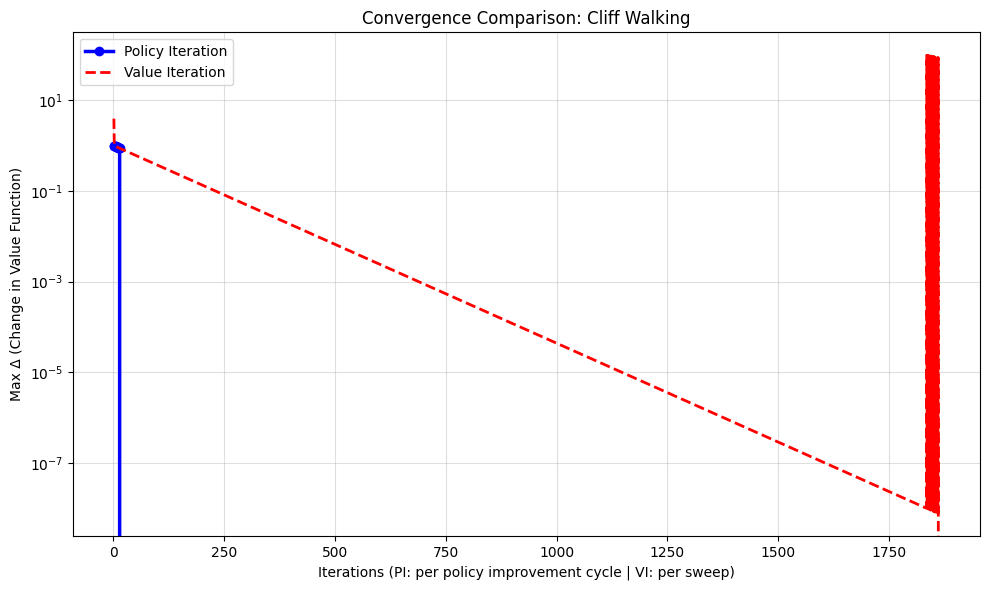

In [7]:
plot_convergence(deltas_vi, deltas_pi, env_name="Cliff Walking")

## Conclusion

In this notebook, we examined **Value Iteration** and **Policy Iteration** in the CliffWalking environment, focusing on how large negative rewards influence convergence and policy structure.

### Key Observations

- **Value Function Characteristics:**  
  The learned value functions clearly reflect the presence of the cliff, with extremely low values along cliff-adjacent states. States farther from the cliff exhibit higher values despite longer paths to the goal, indicating risk-aware planning.

- **Policy Behavior:**  
  Both VI and PI converged to policies that avoid the cliff entirely, preferring safer routes even when they require more steps. This demonstrates that the algorithms correctly internalize long-term expected returns rather than greedy shortest paths.

- **Convergence Dynamics:**  
  Policy Iteration converged in fewer iterations, while Value Iteration showed smoother, incremental updates. In a deterministic environment like CliffWalking, both methods produced nearly identical optimal policies.

- **Empirical Performance:**  
  Evaluation rollouts confirmed stable behavior with consistent returns and no cliff falls, validating the correctness of the learned policies.

### Takeaways

CliffWalking highlights how **reward magnitude and structure** can dominate policy behavior. Even in deterministic environments, dynamic programming methods naturally encode risk sensitivity through expected return maximization. This experiment reinforces the importance of reward design and provides a clear contrast to stochastic environments such as FrozenLake.
